$$\textbf{\Large Amirreza Taheri}$$
$$\textbf{\LARGE Neural Networks and Deep Learning - Assignment 3}$$

## Question 1 – Forecasting the Value of Oil

>   
>   One of the most common applications of memory‑based neural networks is time‑series prediction.
>   In this question you will learn how to forecast the **raw value of crude oil** using four different methods.


#### 1‑1 Dataset and Preparation (20 points)


>   Download the dataset for this question by selecting the **CL = F** symbol on [Yahoo Finance](https://finance.yahoo.com/quote/CL%3DF) for the years 2010 to present, and among the recorded columns select **Adj Close** as the main feature.
>   
>   * On some days no data were recorded; those rows are regarded as **null**.
>   * In addition to the existing **null** rows, randomly delete some other rows.
>   * Then implement substitution methods, fill in the data, and complete the dataset.
>   * In this research the data are treated as a time series, so we split them with the **Temporal Split** method, which guarantees that the validation and test data come *after* the training data in time (and not scattered through the series).

#### What is a Temporal Split?

>   A standard method for partitioning time‑series data into training and test sections **while preserving chronological order**.
>   Unlike random splits that may leak future information, a Temporal Split first feeds *older* data to the model for training and then evaluates on *newer* data, stopping information leakage and better matching real‑world forecasting tasks. For more information see **[this link](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)**.
>   
>   If the validation window is small the **Rolling Forecast Origin** technique can be used to evaluate the model across different time spans. Finally, all data are normalised.
>   


#### What is a Rolling Forecast Origin?

   
>   In this approach the model is updated step‑by‑step with new data, and at every forecasting step the origin moves forward, repeating the process.
>   This results in a more realistic evaluation than a fixed train/test split and resembles real‑world conditions in which models continually receive fresh data. The method allows finer analysis of the model’s behaviour when facing consecutive data and temporal changes. For more information see **[this link](https://otexts.com/fpp3/tscv.html)** or **[this link](https://openforecast.org/adam/rollingOrigin.html)**.


#### 1-2 Model Implementation (45 points)

>   In the referenced article four time‑series forecasting models—**RNN, GRU, LSTM, and Bi‑LSTM**—were implemented while using Mean Square Error as the loss function. Train these four models with **exactly** the hyper‑parameters given in **Table 4** and report all requested items.
>   
>   ##### Table 4 – Hyper‑parameters of LSTM, GRU, and Bi‑LSTM modelling
>   
>   | Hyper‑parameter | Value                            |
>   | --------------- | -------------------------------- |
>   | Learning Rate   | 0.0010                           |
>   | Batch Size      | 100                              |
>   | Optimizer       | Adam                             |
>   | Epochs          | 50                               |
>   | Units           | 512 (LSTM & GRU); 1024 (Bi‑LSTM) |
>   
>   * For each of the three requested models, plot the predicted values **together with** the real values (15 pts).
>   * First give brief definitions of **MAPE, MAE, RMSE, and R‑Squared**, then report the numbers and **analyse and compare** them.


#### 1-3 ARIMA (bonus 10 points)


>   In this part you will become familiar with the classical models **ARIMA** and **SARIMA**; first state their differences.
>   
>   * Explain the mathematical concept of the ARIMA model together with all its parameters.
>   * Find and report the *optimised* parameters for the model.
>   * Provide a table similar to Table 5 in the article and compare your results.

## Answer 1

### Prerequisits

In [1]:
# System and Warnings
import warnings
warnings.filterwarnings("ignore")

# Core Data Handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Yahoo Finance Data
import yfinance as yf

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Sklearn Utilities
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Statsmodels for Classical Time Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


### Functions

In [2]:
# Performance metrics calculation function
def calculate_metrics(y_true, y_pred):
    # Convert back to original scale
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1))
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))
    
    # Calculate metrics
    mse = mean_squared_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    r2 = r2_score(y_true_inv, y_pred_inv)
    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / y_true_inv)) * 100
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        '$R^2$': r2,
        'MAPE': mape
    }

In [3]:
# Model training and evaluation function
def train_and_evaluate_model(model, model_name):
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train the model
    print(f"\nTraining {model_name} model...")
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Plot training history
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.close()
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    metrics = calculate_metrics(y_test, y_pred)
    print(f"\n{model_name} Performance Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    
    # Plot actual vs predicted values
    test_dates = df_filled.index[train_size + val_size + seq_length:].values
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_inv = scaler.inverse_transform(y_pred)
    
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_inv, label='Actual', color='blue')
    plt.plot(test_dates, y_pred_inv, label='Predicted', color='red', linestyle='--')
    plt.title(f'{model_name} - Actual vs Predicted Oil Prices')
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    return metrics, y_test_inv, y_pred_inv

In [4]:
# Create sequences for time series forecasting
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

In [14]:
def train_evaluate_visualize(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, 
                             scaler, df_filled, train_size, val_size, seq_length, shuffle=True):
    # Early stopping to halt training if validation loss stops improving
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    # Train the model
    print(f"\nTraining {model_name}...")
    history = model.fit(X_train, y_train, epochs=50, batch_size=100, 
                        validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0, shuffle=shuffle)
    
    # Predict on test set
    y_pred = model.predict(X_test, verbose=0)
    
    # Inverse transform predictions and actual values to original scale
    y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_orig = scaler.inverse_transform(y_pred.reshape(-1, 1))
    
    # Compute performance metrics
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    mape = np.mean(np.abs((y_test_orig - y_pred_orig) / y_test_orig)) * 100
    r2 = r2_score(y_test_orig, y_pred_orig)
    
    metrics = {'Model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, '$R^2$': r2}
    
    # Plot 1: Actual vs Predicted Values
    test_dates = df_filled.index[train_size + val_size + seq_length: 
                                 train_size + val_size + seq_length + len(y_test)]
    plt.figure(figsize=(12, 6))
    plt.plot(test_dates, y_test_orig, label='Actual', color='blue', linewidth=2)
    plt.plot(test_dates, y_pred_orig, label='Predicted', color='red', linestyle='--', linewidth=2)
    plt.title(f'{model_name}: Actual vs Predicted Oil Prices', fontsize=16, pad=10)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Training and Validation Loss History
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='green', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
    plt.title(f'{model_name}: Training and Validation Loss', fontsize=16, pad=10)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    return metrics, y_pred_orig, history

In [15]:
# Helper Functions 
def adf_test(series):
    """Augmented Dickey-Fuller stationarity test"""
    result = adfuller(series.dropna(), autolag='AIC')
    output = pd.Series(result[:4], index=['Test Statistic','p-value','#Lags Used','Observations'])
    for k, v in result[4].items(): output[f'Critical Value ({k})'] = v
    print(output)
    return result[1] <= 0.05  # stationary if p <= 0.05


def evaluate_forecast(true, pred):
    """Compute performance metrics"""
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

In [16]:
# Forecasting Functions 
def forecast_arima(series, train_size):
    # Split into train/test
    train = series.iloc[:train_size]
    test = series.iloc[train_size:]

    # Stationarity
    print("ADF test on training data:")
    d = 0 if adf_test(train) else 1
    print(f"Selected d = {d}\n")

    # Grid search for p, q
    best_aic, best_order = np.inf, None
    for p in range(0, 5):
        for q in range(0, 5):
            try:
                model = ARIMA(train, order=(p, d, q)).fit()
                if model.aic < best_aic:
                    best_aic, best_order = model.aic, (p, d, q)
            except:
                continue
    print(f"Best ARIMA order: {best_order} (AIC={best_aic:.1f})\n")

    # Fit final ARIMA
    final_model = ARIMA(train, order=best_order).fit()
    forecast = final_model.forecast(steps=len(test))
    metrics = evaluate_forecast(test.values, forecast.values)
    return metrics, test.index, test.values, forecast.values

In [17]:
def forecast_sarima(series, train_size, s=12):
    # Split into train/test
    train = series.iloc[:train_size]
    test = series.iloc[train_size:]

    # Stationarity
    print("ADF test on training data for SARIMA:")
    d = 0 if adf_test(train) else 1
    D = 0 if adf_test(train.diff(s).dropna()) else 1
    print(f"Selected d={d}, D={D}, seasonal period s={s}\n")

    # Grid search for p, q, P, Q
    best_aic, best_order = np.inf, None
    for p in range(0, 3):
        for q in range(0, 3):
            for P in range(0, 2):
                for Q in range(0, 2):
                    try:
                        mod = SARIMAX(train,
                                      order=(p, d, q),
                                      seasonal_order=(P, D, Q, s),
                                      enforce_stationarity=False,
                                      enforce_invertibility=False)
                        res = mod.fit(disp=False)
                        if res.aic < best_aic:
                            best_aic = res.aic
                            best_order = (p, d, q, P, D, Q, s)
                    except:
                        continue
    print(f"Best SARIMA order: {best_order} (AIC={best_aic:.1f})\n")

    # Fit final SARIMA
    final_mod = SARIMAX(train,
                        order=best_order[:3],
                        seasonal_order=best_order[3:],
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
    forecast = final_mod.forecast(steps=len(test))
    metrics = evaluate_forecast(test.values, forecast.values)
    return metrics, test.index, test.values, forecast.values

### Answer 1.1

Use the `yfinance` library to download daily data starting from January 1, 2010, up today and extract the **Adjusted Close** price, which adjusts for splits and dividends to provide a consistent price series.

In [18]:
# Dataset and Preparation
# Download crude oil futures data
print("Downloading crude oil futures data from Yahoo Finance...")
data = yf.download(
    tickers="CL=F",  # WTI crude oil futures
    start="2010-01-01",
    auto_adjust=False,
    progress=False
)

# Extract 'Adjusted Close' column into a new DataFrame
df = data[['Adj Close']].copy()
print(f"Downloaded {len(df)} days of data")

# Show basic info and a sample of the raw data
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows of the downloaded data:")
display(df.head())

Downloaded 3860 days of data

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3860 entries, 2010-01-04 to 2025-05-08
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, CL=F)  3860 non-null   float64
dtypes: float64(1)
memory usage: 60.3 KB
None

First 5 rows of the downloaded data:


Price,Adj Close
Ticker,CL=F
Date,
2010-01-04,81.510002
2010-01-05,81.769997
2010-01-06,83.180000
2010-01-07,82.660004
2010-01-08,82.750000


In this part, I do the beklow tasks:

- Check for existing missing values (e.g., from non-trading days).  
- Randomly introduce additional missing values (5% of rows) to mimic real-world imperfections.  
- Fill all gaps using linear interpolation to maintain the time-series trend.

**Linear Interpolation:**

It estimates missing values as:
  $$
  x_t = x_{t-1} + \frac{t - (t-1)}{(t+1) - (t-1)} \cdot (x_{t+1} - x_{t-1})
  $$

This assumes a smooth trends, suitable for high frquency financial data with small gaps  where prices change gradually.

  - **Forward Fill:** $x_t = x_{t-1}$, risking bias.
  - **Backward Fill:** $x_t = x_{t+1}$, similarly limited.
  - **Polynomial:** Fits a polynomial of a specified degree (e.g., quadratic) through known points to estimate missing values.
  - **Spline:** Fits piecewise cubic polynomials between points, ensuring smoothness (continuous first and second derivatives).
  - **Nearest Neighbor:** Fills missing values with the nearest available value, either from the previous (forward fill) or next (backward fill) data point. By extending this concept we get K-Nearest-Neoghbor interpolation approach.
  - **Time Interpolation:** Interpolates based on the time index, similar to linear interpolation but explicitly using timestamp differences. Essentially is equivalent to linear interpolation for daily data with regular spacing.

In [19]:
# Check initial missing values
initial_nulls = df['Adj Close'].isnull().sum()
print(f"Initial missing values: {initial_nulls}")

# Simulate missing data by randomly setting 5% of values to NaN
missing_indices = np.random.choice(df.index, size=int(0.05 * len(df)), replace=False)
df.loc[missing_indices, 'Adj Close'] = np.nan
print(f"Missing values after random deletion: {df['Adj Close'].isnull().sum()}")
# Perform linear interpolation
df_filled = df.copy()
df_filled['Adj Close'] = df_filled['Adj Close'].interpolate(method='linear')
print(f"Missing values after interpolation: {df_filled['Adj Close'].isnull().sum()}")

Initial missing values: Ticker
CL=F    0
dtype: int64
Missing values after random deletion: Ticker
CL=F    193
dtype: int64
Missing values after interpolation: Ticker
CL=F    0
dtype: int64


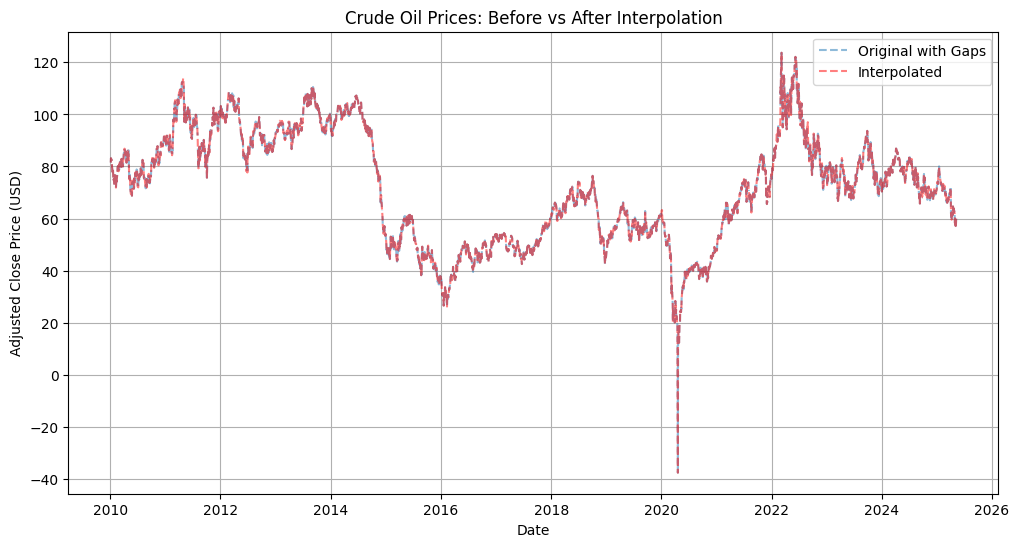

In [20]:
# Visualize the effect of interpolation
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Adj Close'], label='Original with Gaps', alpha=0.5, linestyle='--')
plt.plot(df_filled.index, df_filled['Adj Close'], label='Interpolated', color='red', alpha=0.5, linestyle='--')
plt.title('Crude Oil Prices: Before vs After Interpolation')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

Here, I allocate 70% for training, 15% for validation, and 15% for testing.

In [21]:
# Calculate split sizes
train_size = int(len(df_filled) * 0.7)
val_size = int(len(df_filled) * 0.15)
test_size = len(df_filled) - train_size - val_size

In [22]:
# Perform temporal split
train_data = df_filled.iloc[:train_size]
val_data = df_filled.iloc[train_size:train_size + val_size]
test_data = df_filled.iloc[train_size + val_size:]

In [23]:
# Print split details with date ranges
print(f"Training data: {len(train_data)} days ({train_data.index[0]} to {train_data.index[-1]})")
print(f"Validation data: {len(val_data)} days ({val_data.index[0]} to {val_data.index[-1]})")
print(f"Test data: {len(test_data)} days ({test_data.index[0]} to {test_data.index[-1]})")

Training data: 2702 days (2010-01-04 00:00:00 to 2020-09-29 00:00:00)
Validation data: 579 days (2020-09-30 00:00:00 to 2023-01-18 00:00:00)
Test data: 579 days (2023-01-19 00:00:00 to 2025-05-08 00:00:00)


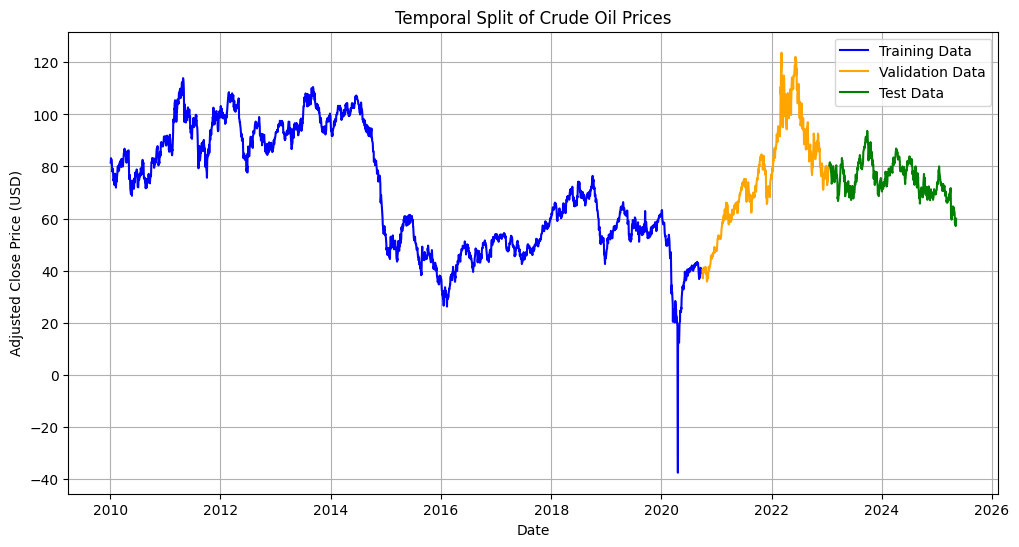

In [24]:
# Visualize the splits
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Adj Close'], label='Training Data', color='blue')
plt.plot(val_data.index, val_data['Adj Close'], label='Validation Data', color='orange')
plt.plot(test_data.index, test_data['Adj Close'], label='Test Data', color='green')
plt.title('Temporal Split of Crude Oil Prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

I apply `MinMaxScaler` to scale the data to a \[0, 1\] range to improve model training stability.  

In [25]:
# Initialize and apply the scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_filled[['Adj Close']].values)

# Re-split the scaled data
train_data_scaled = scaled_data[:train_size]
val_data_scaled = scaled_data[train_size:train_size + val_size]
test_data_scaled = scaled_data[train_size + val_size:]

# Show min/max of original and scaled data for verification
print(f"Original data min: {df_filled['Adj Close'].min()}, max: {df_filled['Adj Close'].max()}")
print(f"Scaled data min: {scaled_data.min()}, max: {scaled_data.max()}")
print("\nSample of scaled training data (first 5 values):")
print(train_data_scaled[:5].flatten())

Original data min: Ticker
CL=F   -37.630001
dtype: float64, max: Ticker
CL=F    123.699997
dtype: float64
Scaled data min: 0.0, max: 1.0

Sample of scaled training data (first 5 values):
[0.73848636 0.74009793 0.7488378  0.74561462 0.74617246]


In [26]:
# Define sequence length and create sequences
seq_length = 60

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])  # Input: past 60 days
        y.append(data[i + seq_length])    # Target: next day
    return np.array(X), np.array(y)

In [27]:
# Generate training sequences
X_train, y_train = create_sequences(train_data_scaled, seq_length)
# Generate sequences for each split
X_train, y_train = create_sequences(train_data_scaled, seq_length)
X_val, y_val = create_sequences(val_data_scaled, seq_length)
X_test, y_test = create_sequences(test_data_scaled, seq_length)

# Select the first sequence and its target for plotting
sample_sequence = X_train[0].flatten()  # First 60-day sequence
sample_target = y_train[0][0]          # Corresponding target (61st day)
sample_dates = df_filled.index[:seq_length].to_list() + [df_filled.index[seq_length]]

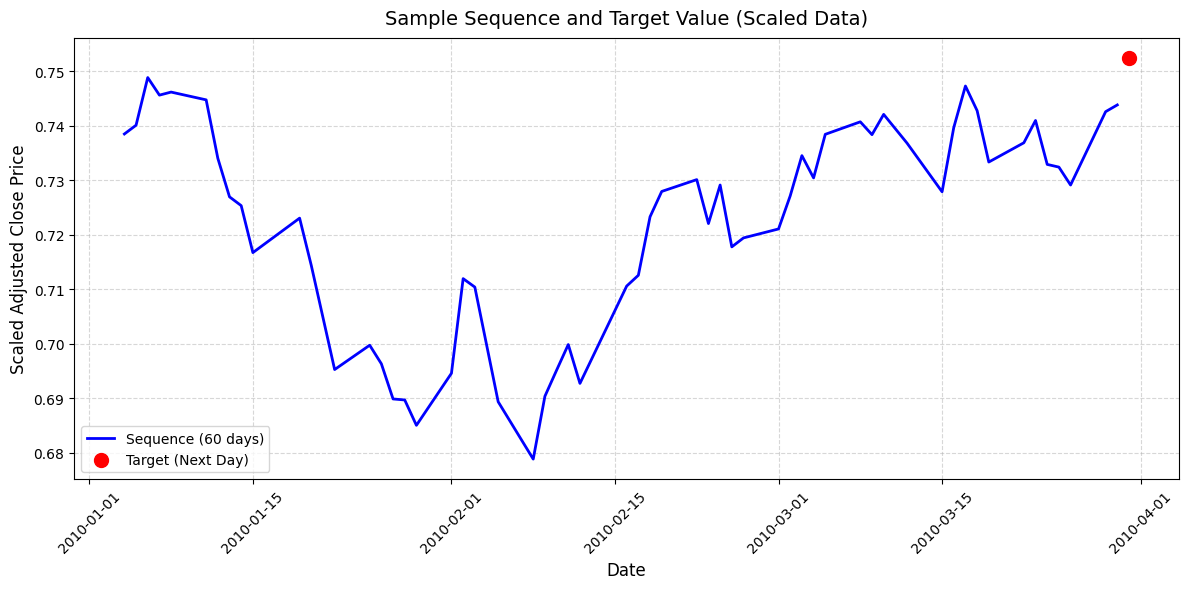


Sample sequence (first 5 scaled values): [0.73848636 0.74009793 0.7488378  0.74561462 0.74617246]
Target (scaled): 0.7524

Sample sequence (first 5 original values): [81.51000214 81.76999664 83.18000031 82.66000366 82.75      ]
Target (original): 83.76


In [28]:
# Plot the sequence and target
plt.figure(figsize=(12, 6))
plt.plot(sample_dates[:seq_length], sample_sequence, label='Sequence (60 days)', color='blue', linewidth=2)
plt.scatter(sample_dates[seq_length], sample_target, color='red', s=100, label='Target (Next Day)', zorder=5)
plt.title('Sample Sequence and Target Value (Scaled Data)', fontsize=14, pad=10)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Scaled Adjusted Close Price', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: Show the sequence and target in original scale for context
sequence_orig = scaler.inverse_transform(sample_sequence.reshape(-1, 1)).flatten()
target_orig = scaler.inverse_transform([[sample_target]])[0][0]
print("\nSample sequence (first 5 scaled values):", sample_sequence[:5])
print(f"Target (scaled): {sample_target:.4f}")
print("\nSample sequence (first 5 original values):", sequence_orig[:5])
print(f"Target (original): {target_orig:.2f}")

### Answer 1.2

In [29]:
# Hyperparameters
learning_rate = 0.001
units = 512

Building Simple RNN...

Training Simple RNN...


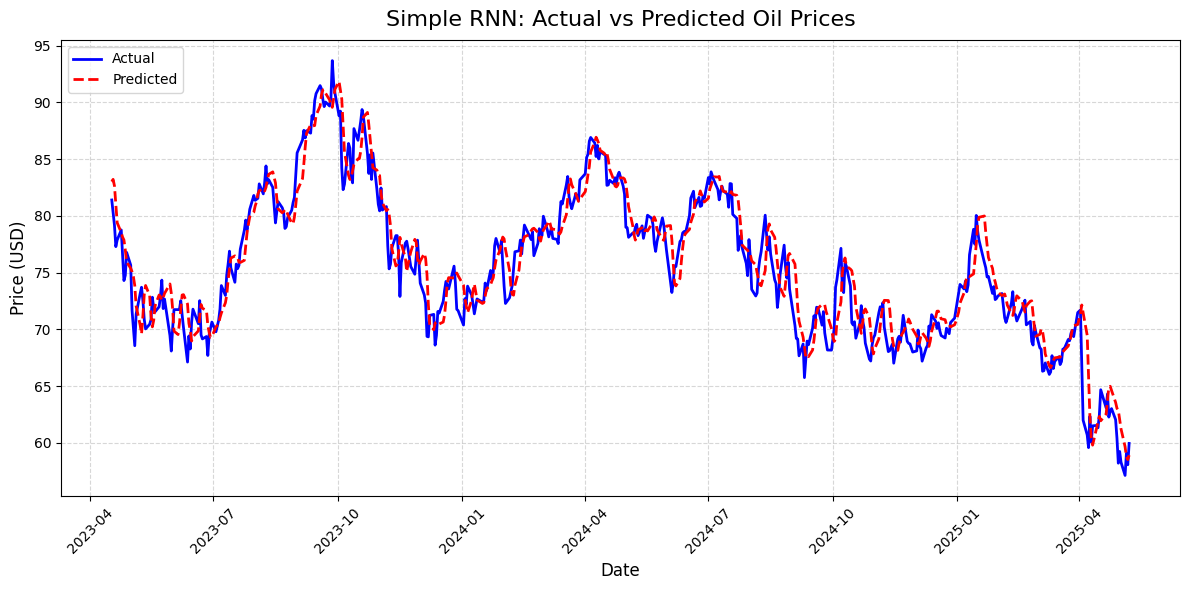

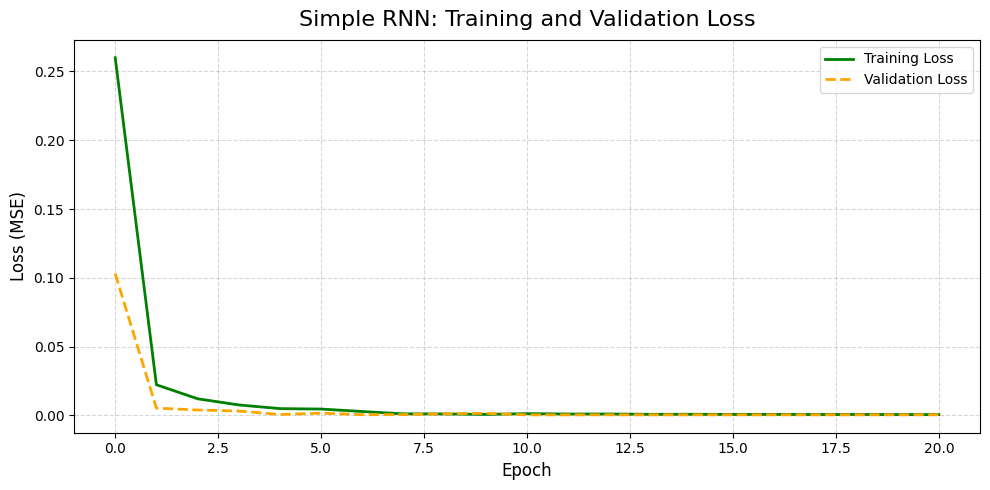

In [30]:
# Simple RNN
print("Building Simple RNN...")
rnn_model = Sequential([
    SimpleRNN(units, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])
rnn_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
rnn_metrics, rnn_pred, rnn_history = train_evaluate_visualize(
    rnn_model, 'Simple RNN', X_train, y_train, X_val, y_val, X_test, y_test, 
    scaler, df_filled, train_size, val_size, seq_length
)

Building GRU...

Training GRU...


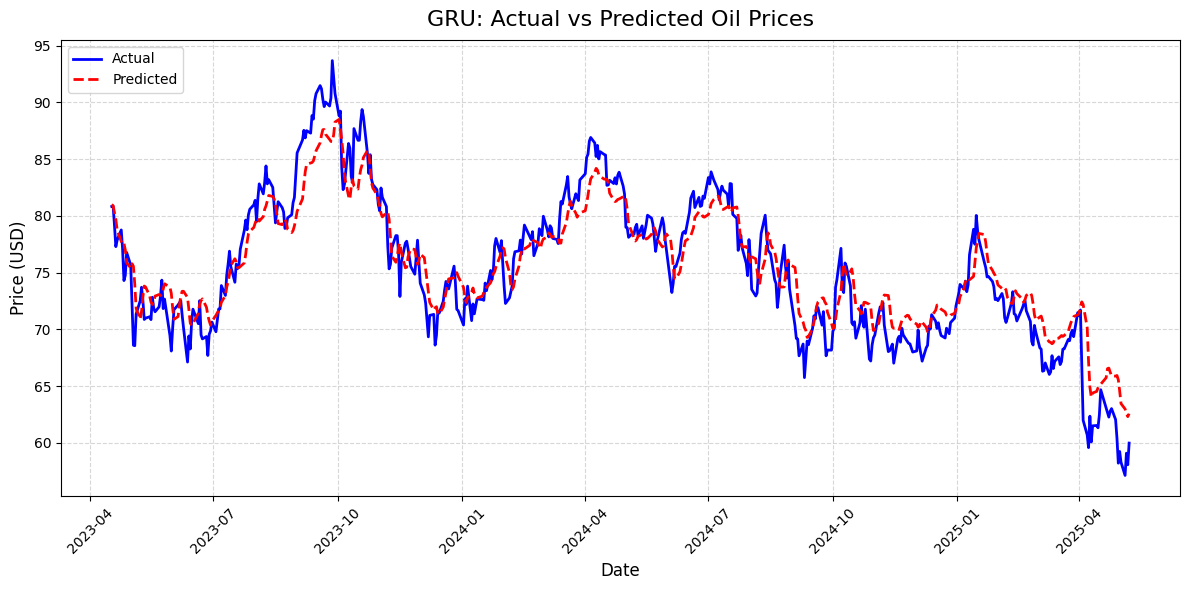

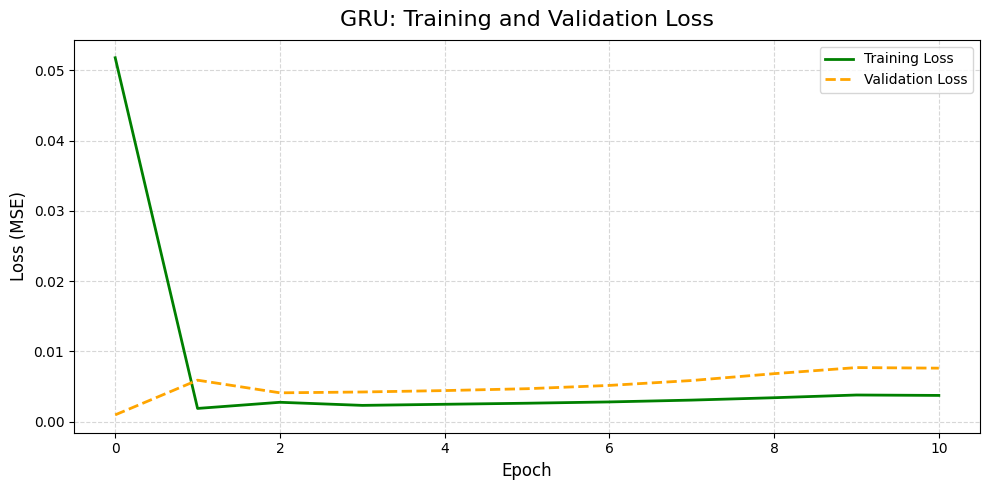

In [22]:
# GRU
print("Building GRU...")
gru_model = Sequential([
    GRU(units, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])
gru_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
gru_metrics, gru_pred, gru_history = train_evaluate_visualize(
    gru_model, 'GRU', X_train, y_train, X_val, y_val, X_test, y_test, 
    scaler, df_filled, train_size, val_size, seq_length
)

Building LSTM...

Training LSTM...


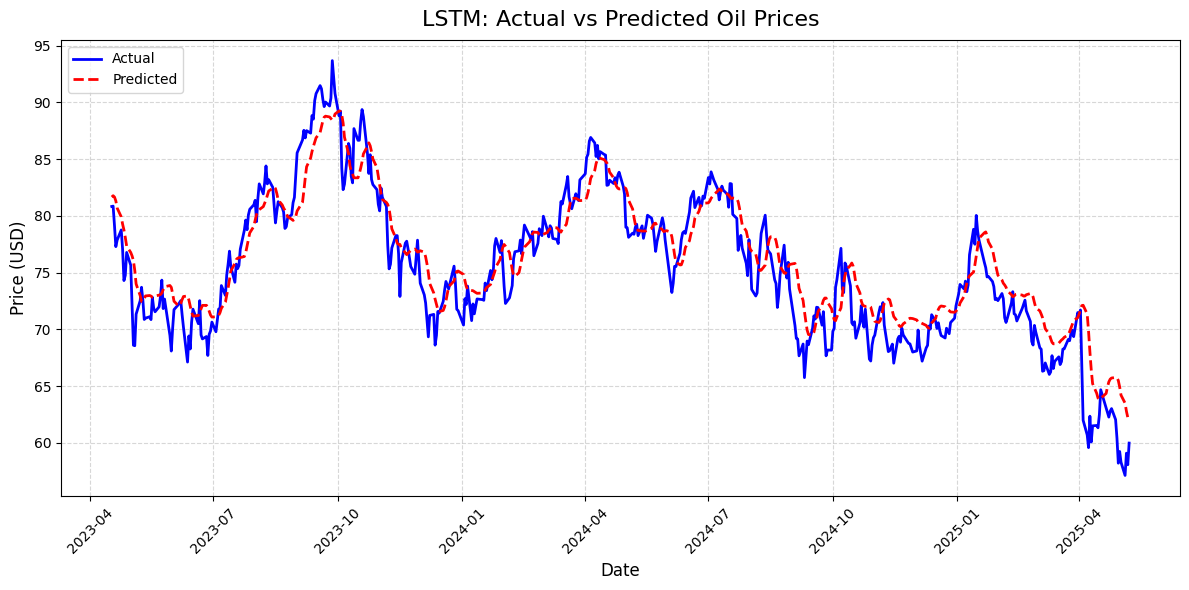

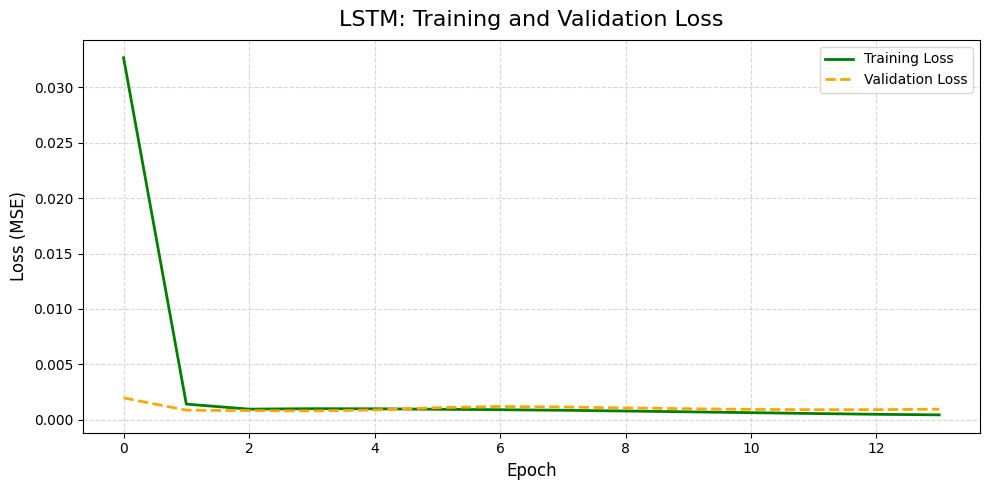

In [23]:
# LSTM
print("Building LSTM...")
lstm_model = Sequential([
    LSTM(units, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
lstm_metrics, lstm_pred, lstm_history = train_evaluate_visualize(
    lstm_model, 'LSTM', X_train, y_train, X_val, y_val, X_test, y_test, 
    scaler, df_filled, train_size, val_size, seq_length
)

In [ ]:
# Bi-LSTM
print("Building Bi-LSTM...")
bilstm_model = Sequential([
    Bidirectional(LSTM(units, activation='tanh'), input_shape=(seq_length, 1)),
    Dense(1)
])
bilstm_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
bilstm_metrics, bilstm_pred, bilstm_history = train_evaluate_visualize(
    bilstm_model, 'Bi-LSTM', X_train, y_train, X_val, y_val, X_test, y_test, 
    scaler, df_filled, train_size, val_size, seq_length
)

Building Bi-LSTM...

Training Bi-LSTM...


- **MAPE (Mean Absolute Percentage Error):**  
  $$
  MAPE = \frac{100\%}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|
  $$  
  *Relative error in percentage; sensitive to small actual values.*


- **MAE (Mean Absolute Error):**  
  $$
  MAE = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
  $$  
  *Average error in USD.*

- **RMSE (Root Mean Squared Error):**  
  $$
  RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}
  $$  
  *Square root of average squared errors.*


- **R-Squared ($R^2$):**  
  $$
  R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
  $$  
  *Goodness-of-fit; 1 indicates perfect prediction.*


In [ ]:
# Compile metrics into a DataFrame
metrics_df = pd.DataFrame([rnn_metrics, gru_metrics, lstm_metrics, bilstm_metrics])

# Round values for readability
metrics_df = metrics_df.round({'MSE': 2, 'RMSE': 2, 'MAE': 2, 'MAPE': 2, '$R^2$': 3})

# Display formatted table
print("\nModel Performance Summary:")
display(metrics_df)

# Identify best model by RMSE
best_model = metrics_df.loc[metrics_df['RMSE'].idxmin(), 'Model']
print(f"\nBest model (lowest RMSE): {best_model}")

In [ ]:
display(metrics_df.style.set_caption("Performance Metrics").set_table_styles([
    {'selector': 'caption', 'props': 'font-size:16px; font-weight:bold;'},
    {'selector': 'th', 'props': 'text-align:center;'},
    {'selector': 'td', 'props': 'text-align:center;'}
]))

In [ ]:
# Bar chart for RMSE and MAE comparison
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(metrics_df['Model']))
# Bar chart for RMSE, MAE, and MAPE comparison
plt.figure(figsize=(12, 6))
bar_width = 0.25  # Adjusted for three bars
index = np.arange(len(metrics_df['Model']))

# Plot bars for each metric
plt.bar(index, metrics_df['RMSE'], bar_width, label='RMSE ($)', color='skyblue')
plt.bar(index + bar_width, metrics_df['MAE'], bar_width, label='MAE ($)', color='salmon')
plt.bar(index + 2 * bar_width, metrics_df['MAPE'], bar_width, label='MAPE (%)', color='limegreen')

# Customize the plot
plt.xlabel('Model', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Model Comparison: RMSE, MAE, and MAPE', fontsize=16, pad=10)
plt.xticks(index + bar_width, metrics_df['Model'], fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### Results Analysis

GRU has the best performance, with the lowest errors and highest $R^2$. Its edge stems from its gating mechanisms—the update and reset gates—that manages temporal dependencies, handling vanishing gradient while it is not as computational expensive as the more complex structures.

Simple RNN’s has by far the worst performance which is showing why basic architectures fail with long-term patterns, like oil market cycles, indicating the need for more advanced models like GRU and LSTM. On the other hand Bi-LSTM’s slight edge over LSTM (MSE: 5.21 vs. 4.90, $R^2$: 0.8806 vs. 0.8876) hints that bidirectional processing adds little value for this forward-looking price data, suggesting the extra complexity might not be necessary when unidirectional models already captures the critical patterns.

In [ ]:
# Combined plot of all predictions
test_dates = df_filled.index[train_size + val_size + seq_length: 
                            train_size + val_size + seq_length + len(y_test)]
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_orig, label='Actual', color='blue', linewidth=2.5)
plt.plot(test_dates, rnn_pred, label='Simple RNN', color='green', linestyle='--', alpha=0.7)
plt.plot(test_dates, gru_pred, label='GRU', color='red', linestyle='-.', alpha=0.7)
plt.plot(test_dates, lstm_pred, label='LSTM', color='purple', linestyle=':', alpha=0.7)
plt.plot(test_dates, bilstm_pred, label='Bi-LSTM', color='orange', linestyle='--', alpha=0.7)
plt.title('All Models: Actual vs Predicted Oil Prices', fontsize=16, pad=10)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=10, bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Answer 1.3

The **ARIMA (AutoRegressive Integrated Moving Average)** model is a classical statistical method for time series forecasting. It is defined by three parameters: $(p, d, q)$, where:

- $p$: Number of lag observations (AutoRegressive terms).
- $d$: Number of times the data is differenced to make it stationary (Integrated terms).
- $q$: Size of the moving average window (Moving Average terms).

The model assumes a linear relationship between past values and errors to predict future values. Mathematically, an ARIMA model can be expressed as:

$$
y_t' = c + \phi_1 y_{t-1}' + \phi_2 y_{t-2}' + \cdots + \phi_p y_{t-p}' + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \cdots + \theta_q \epsilon_{t-q} + \epsilon_t
$$

- $y_t'$: Differenced time series (if $d > 0$).
- $\phi_i$: AR coefficients.
- $\theta_j$: MA coefficients.
- $\epsilon_t$: White noise error term.

SARIMA (Seasonal ARIMA) extends ARIMA by adding seasonal components $(P, D, Q, s)$ to model time series with both non-seasonal and seasonal patterns, where $s$ is the seasonal period.

In [ ]:
df_filled.index = pd.DatetimeIndex(df_filled.index)       # ensure it's a DateTimeIndex
df_filled = df_filled.sort_index()                        # make sure it's sorted
# force a business‐day frequency
inferred = pd.infer_freq(df_filled.index)
if inferred is None:
    # fallback to business day frequency
    df_filled = df_filled.asfreq('B')
else:
    df_filled.index.freq = inferred

series = df_filled['Adj Close']
metrics_arima, idx_arima, true_arima, pred_arima = forecast_arima(series, train_size)
metrics_sarima, idx_sarima, true_sarima, pred_sarima = forecast_sarima(series, train_size, s=252)

# Results Table
results = pd.DataFrame([metrics_arima, metrics_sarima], index=['ARIMA', 'SARIMA'])
print("\nComparison Table:")
display(results.round(3))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(idx_arima, true_arima, label='Actual', color='black')
plt.plot(idx_arima, pred_arima, label='ARIMA Forecast', linestyle='--')
plt.plot(idx_sarima, pred_sarima, label='SARIMA Forecast', linestyle=':')
plt.title('ARIMA vs SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

## Question 2 – Predicting Suicidal Ideation on Social Media

#### Introduction

>   The goal of this exercise is to detect suicidal thoughts in a set of Twitter data.
>   The referenced article examined several classical and deep‑learning methods and found that deep‑learning models perform best.
>   
>   Using the data supplied for this assignment (tweet text + suicide/non‑suicide label), you must evaluate three deep‑learning models:
>   
>   * **LSTM**
>   * **2‑layer LSTM**
>   * **CNN + 2‑layer LSTM**
>   
>   Where the article omits hyper‑parameters (learning rate, neurons, …) you may choose reasonable values.

#### 2‑1 Data Pre‑Processing (30 points)


>   Carry out **all** preprocessing steps stated in the article—stemming, stop‑word removal, deleting punctuation, removing repeated letters, etc.—your processed data is expected to look like:
>   
>   **Text 1**
>   
>   > `my life is meaningless i just want to end my life so badly my life is completely empty and i dont want to have to create meaning in it creating meaning is pain how long will i hold back the urge to run my car head ﬁrst into the next person coming the opposite way when will i stop feeling jealous of tragic characters like gomer pile for the swift end they were able to bring to their lives`
>   
>   **Text 2**
>   
>   > `life meaningless want end life badly life completely empty dont want create meaning creating  meaning  pain  long  hold  back  urge  run  car  head  ﬁrst  next  person  coming opposite way stop feeling jealous tragic character like gomer pile swift end able bring life`


#### 2‑2 Building the Embedding Matrix (10 points)

>   As instructed in the article, create the **embedding matrix** from a pre‑trained **Word2Vec** model and briefly describe its properties.
>   
>   *Bonus (5 pts):* Investigate other popular embedding methods and, if desired, use them.

#### 2‑3 Training Deep‑Learning Models (50 points)


>   Design and train the three models—**LSTM, 2‑layer LSTM, and CNN + 2‑layer LSTM**—with the pre‑processed data. A short description for each model is provided:
>   
>   * **Long Short‑Term Memory (LSTM)** – an advanced RNN designed to capture long‑distance dependencies via memory cells and gates.
>   * **2‑layer LSTM** – two stacked LSTM layers; the deeper structure allows the model to learn more complex patterns.
>   * **CNN + 2‑layer LSTM** – first a CNN extracts local features from text, then a two‑layer LSTM analyses temporal dependencies.
>   
>   *Note:* You may hit a dimensionality error when building **CNN + 2‑layer LSTM**; inserting a **Reshape** layer resolves it. Other solutions exist; see *[source 1](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)*, *[source 2](https://machinelearningmastery.com/stacked-long-short-term-memory-networks/)*, or *[source 3](https://www.analyticsvidhya.com/blog/2021/06/lstm-for-text-classification/)*.
>   


#### 2‑4 Results and Analysis (10 points)

>   
>   Plot **accuracy and loss versus epochs** for the three models, analyse convergence, detect under‑ or over‑fitting, and discuss:
>   
>   * Which model achieved the highest validation accuracy.
>   * Which converged fastest.
>   * How each performed on unseen data.

## Answer 2

In [ ]:
# System and Warnings
import os
import warnings
warnings.filterwarnings("ignore")

# Data Handling and Text Processing
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# NLTK Resource Downloads
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Pretrained Word Embeddings
import gensim.downloader as api
from gensim.models import KeyedVectors

# TensorFlow / Keras (NLP Models)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
# Load the dataset
data = pd.read_csv('twitter-suicidal_data.csv')

In [ ]:
# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [ ]:

def preprocess_text(text):
    # Handle non-string input (e.g., NaN or float)
    if not isinstance(text, str):
        return ""
    
    # Step 1: Convert to lowercase
    text = text.lower()
    
    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Step 3: Remove punctuation and special characters (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Step 4: Tokenize into words
    words = word_tokenize(text)
    
    # Step 5: Remove repeated letters (e.g., "sooo" -> "soo")
    words = [re.sub(r'(\w)\1{2,}', r'\1\1', word) for word in words]
    
    # Step 6: Remove stop words
    words = [word for word in words if word not in stop_words]
    
    # Step 7: Lemmatize words
    words = [lemmatizer.lemmatize(word) for word in words]
    
    # Step 8: Remove duplicate consecutive words
    filtered_words = []
    prev_word = None
    for word in words:
        if word != prev_word:
            filtered_words.append(word)
        prev_word = word
    
    # Step 9: Join tokens back into a string
    processed_text = ' '.join(filtered_words)
    return processed_text

# Apply preprocessing to the 'tweet' column
data['processed_tweet'] = data['tweet'].apply(preprocess_text)

# Print the first 5 rows to verify preprocessing
for row in data.head(5).itertuples():
    print(f"Row {row.Index}:")
    print(f"Tweet: {row.tweet}")
    print(f"Intention: {row.intention}")
    print(f"Processed Tweet: {row.processed_tweet}")
    print("-" * 50)

In [ ]:
# Define path to save/load the Word2Vec model
word2vec_path = 'word2vec-google-news-300.model'

# Function to load or download Word2Vec model
def load_word2vec_model():
    if os.path.exists(word2vec_path):
        print(f"Loading Word2Vec model from {word2vec_path}...")
        return KeyedVectors.load(word2vec_path)
    else:
        print("Downloading Word2Vec model...")
        model = api.load('word2vec-google-news-300')
        print(f"Saving Word2Vec model to {word2vec_path}...")
        model.save(word2vec_path)
        return model

# Load the Word2Vec model
word2vec_model = load_word2vec_model()

In [ ]:
# Filter rows where intention == 0 and get the first 3
filtered_data = data[data['intention'] == 0].head(3)

# Print the first 3 rows with intention == 0 in the specified format
print("First 3 rows with intention value 0:")
for row in filtered_data.itertuples():
    print(f"Row {row.Index}:")
    print(f"Tweet: {row.tweet}")
    print(f"Intention: {row.intention}")
    print(f"Processed Tweet: {row.processed_tweet}")
    print("-" * 50)

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['processed_tweet'])

In [ ]:
# Define vocabulary size
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for padding token

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
embedding_dim = 300
embedding_matrix = np.zeros((vocab_size, embedding_dim))

In [ ]:
for word, index in word_index.items():
    if word in word2vec_model:
        embedding_matrix[index] = word2vec_model[word]

In [ ]:
x = Conv1D(64, 3, activation='relu')(embedding_output)
x = MaxPooling1D(2)(x)  # Output shape: (batch_size, steps, 64)
x = LSTM(128, return_sequences=True)(x)  # Accepts 3D input directly

In [ ]:
# Model 1: LSTM
model_lstm = Sequential()
model_lstm.add(Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False))
model_lstm.add(LSTM(128, dropout=0.5))
model_lstm.add(Dense(1, activation='sigmoid'))

# Model 2: 2-Layer LSTM
model_2lstm = Sequential()
model_2lstm.add(Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False))
model_2lstm.add(LSTM(128, return_sequences=True, dropout=0.5))
model_2lstm.add(LSTM(128, dropout=0.5))
model_2lstm.add(Dense(1, activation='sigmoid'))

# Model 3: CNN + 2-Layer LSTM
model_cnn_lstm = Sequential()
model_cnn_lstm.add(Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], trainable=False))
model_cnn_lstm.add(Conv1D(64, 3, activation='relu'))
model_cnn_lstm.add(MaxPooling1D(2))
model_cnn_lstm.add(LSTM(128, return_sequences=True, dropout=0.5))
model_cnn_lstm.add(LSTM(128, dropout=0.5))
model_cnn_lstm.add(Dense(1, activation='sigmoid'))

# Compile and train all models
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

In [ ]:
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, callbacks=[early_stopping])

In [ ]:
model_2lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_2lstm.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, callbacks=[early_stopping])

In [ ]:
model_cnn_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_cnn_lstm.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, callbacks=[early_stopping])